In [9]:
# Importations pour la construction du modèle
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dropout

# Importation pour la transformation sur les images
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.layers import Resizing
from tensorflow.keras.layers import RandomFlip
from tensorflow.keras.layers import RandomZoom
from tensorflow.keras.layers import RandomRotation
from tensorflow.keras.layers import RandomBrightness
from tensorflow.keras.layers import RandomContrast
from tensorflow.keras.layers import RandomTranslation

# Importation de l'utilitaire image_dataset_from_directory de Keras
from keras.utils import image_dataset_from_directory

# Importation pour les visualisations
import matplotlib.pyplot as plt
%matplotlib inline

In [10]:
'''
import tensorflow as tf
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.01,
    zoom_range=[0.9, 1.1],
    horizontal_flip=True,
    fill_mode='nearest')
    '''

"\nimport tensorflow as tf\ndatagen = tf.keras.preprocessing.image.ImageDataGenerator(\n    rotation_range=15,\n    width_shift_range=0.1,\n    height_shift_range=0.1,\n    shear_range=0.01,\n    zoom_range=[0.9, 1.1],\n    horizontal_flip=True,\n    fill_mode='nearest')\n    "

In [11]:
batch_size = 32
img_height = 256
img_width = 256

In [12]:
data_dir = "/home/henri/PycharmProjects/JupyterProject/FG_project-template-main/data/reco_plantes"

train_ds = image_dataset_from_directory(data_dir,
                                        labels="inferred",
                                        label_mode="categorical",
                                        color_mode="grayscale",
                                        batch_size = batch_size,
                                        image_size=(img_height, img_width),
                                        shuffle=True,
                                        validation_split = 0.2,
                                        subset = "training",
                                        seed = 42
                                        )


val_ds = image_dataset_from_directory(data_dir,
                                      labels="inferred",
                                      label_mode="categorical",
                                      color_mode="grayscale",
                                      batch_size = batch_size,
                                      image_size=(img_height, img_width),
                                      shuffle=True,
                                      validation_split = 0.1,
                                      subset = "validation",
                                      seed = 42
                                      )



Found 101871 files belonging to 50 classes.
Using 81497 files for training.
Found 101871 files belonging to 50 classes.
Using 10187 files for validation.


In [13]:
print(type(train_ds))

<class 'tensorflow.python.data.ops.prefetch_op._PrefetchDataset'>


In [14]:
# help(train_ds)

In [15]:
print(len(train_ds))

2547


In [16]:
class_names = train_ds.class_names
print(class_names)
print(len(class_names))

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Black-grass___healthy', 'Blueberry___healthy', 'Charlock___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Cleavers___healthy', 'Common Chickweed___healthy', 'Common wheat___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Fat Hen___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Loose Silky-bent___healthy', 'Maize___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper_bell___Bacterial_spot', 'Pepper_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Scentless Mayweed____healthy', 'Shepherd’s Purse____healthy', 'Small-flowered Cranesbill____healthy', 'S

In [17]:
"""
target = 2500
def balanced(klass):
  class_names = klass
  for images in class_names:
   if len(label) < target:
    images.datagen()
   elif len(label) > target:
"""


'\ntarget = 2500\ndef balanced(klass):\n  class_names = klass\n  for images in class_names:\n   if len(label) < target:\n    images.datagen()\n   elif len(label) > target:\n'

In [18]:
# Nombre de lot dans l'ensemble d'entraînement
print("Nombre de batch dans train_ds:", train_ds.cardinality().numpy())

# Nombre de lot dans l'ensemble de validation
print("Nombre de batch dans val_ds:", val_ds.cardinality().numpy())

Nombre de batch dans train_ds: 2547
Nombre de batch dans val_ds: 319


2026-02-04 14:07:55.701613: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


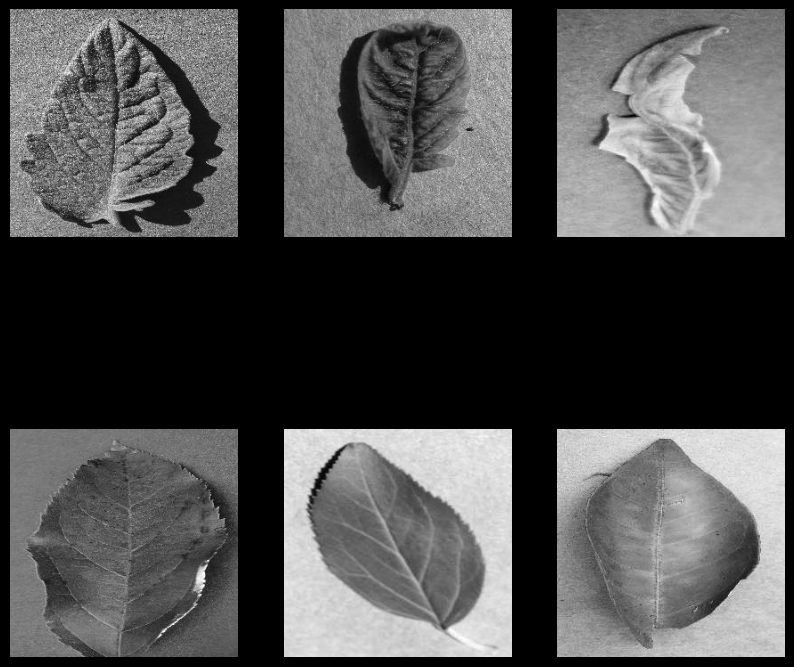

In [19]:
import tensorflow as tf
# Définir le nombre d'images à afficher
number_of_images = 6

# Créer une figure pour l'affichage
plt.figure(figsize=(10,10))

# Obtenir un batch d'images depuis train_ds
for images, labels in train_ds.take(1):
    # Afficher les images du batch
    for i in range(number_of_images):
        ax = plt.subplot(2, 3, i + 1)
        plt.imshow(tf.squeeze(images[i]), cmap='gray')  # Convertir l'image en entier pour l'affichage
        plt.axis("off")
        #plt.title(f"Class of plant: {labels[i].numpy()}")  # Afficher le label de l'image (+18 car nos données d'age commence à 18 et nos labels à 0)

# Afficher les images
plt.show()

In [20]:
import numpy as np
# Get the number of classes from the training labels
num_classes = len(np.unique(train_ds.class_names))
print(num_classes)
# Define the input shape based on the preprocessed images
#input_shape = train_ds.shape[1:] # (height, width, channels)
#print(input_shape)

50


In [21]:
input_shape=(256, 256, 1)

In [22]:
from tensorflow.keras.callbacks import Callback
from timeit import default_timer as timer

class TimingCallback(Callback):
   def __init__(self, epoch_times={}):
       super().__init__()
       self.epoch_times=[]
   def on_epoch_begin(self, epoch, epoch_times={}):
       self.starttime = timer()
   def on_epoch_end(self, epoch, epoch_times={}):
        self.epoch_times.append(timer() - self.starttime)

In [23]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping( monitor='val_loss',
                            min_delta=0.01,
                            patience=3,
                            verbose=1,
                            restore_best_weights = True)

reduce_learning_rate = ReduceLROnPlateau( monitor='val_loss',
                                         patience=2,
                                         min_delta=0.01,
                                         factor=0.1,
                                         cooldown=4,
                                         verbose=1)

checkpoint = ModelCheckpoint('best_model.h5',
                              save_best_only=True,
                              monitor='val_loss',
                              mode='min')

time_callback = TimingCallback()

In [24]:
'''
# Définition de l'entrée du modèle
inputs = Input(shape=(256, 256, 1))

# Transformation des images : redimensionnement, normalisation et augmentation
x = Resizing(50, 50)(inputs)    # Redimensionner les images à 100x100 pixels
x = Rescaling(1./255)(x)        # Normalisation des pixels pour avoir des valeurs entre 0 et 1
x = RandomFlip("horizontal")(x) # Retourner les images horizontalement de façon aléatoire
x = RandomRotation(0.2)(x)      # Appliquer une rotation aléatoire entre -0.2 et +0.2
x = RandomZoom(0.2)(x)          # Appliquer un zoom aléatoire entre 0.8 et 1.2
x = RandomContrast(0.2)(x)      # Modifier le contraste de l'image de façon aléatoire
x = RandomBrightness(0.1)(x)    # Appliquer une variation de la luminosité de l'image de -0.1 à +0.1
'''

'\n# Définition de l\'entrée du modèle\ninputs = Input(shape=(256, 256, 1))\n\n# Transformation des images : redimensionnement, normalisation et augmentation\nx = Resizing(50, 50)(inputs)    # Redimensionner les images à 100x100 pixels\nx = Rescaling(1./255)(x)        # Normalisation des pixels pour avoir des valeurs entre 0 et 1\nx = RandomFlip("horizontal")(x) # Retourner les images horizontalement de façon aléatoire\nx = RandomRotation(0.2)(x)      # Appliquer une rotation aléatoire entre -0.2 et +0.2\nx = RandomZoom(0.2)(x)          # Appliquer un zoom aléatoire entre 0.8 et 1.2\nx = RandomContrast(0.2)(x)      # Modifier le contraste de l\'image de façon aléatoire\nx = RandomBrightness(0.1)(x)    # Appliquer une variation de la luminosité de l\'image de -0.1 à +0.1\n'

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Rescaling, Conv2D, MaxPooling2D, Flatten, Dense


#Create a Sequential model instance.
model = Sequential()

##Normalisation  au début du modèle avec model.add() ou en modifiant la structure du modèle.
model.add(Rescaling(scale=1./255.0, offset=0.0, input_shape=input_shape))

# Add a Conv2D layer
model.add(Conv2D(16, (5, 5), activation='relu', input_shape=input_shape))
model.add(MaxPooling2D((2, 2)))


model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# Flatten the output with GlobalAveragePooling2D
model.add(GlobalAveragePooling2D())

# Add one or more Dense layers
#model.add(Dense(256, activation='relu'))
#model.add(Dropout(0.2))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))

#  Add a final Dense layer for classification
model.add(Dense(num_classes, activation='softmax')) # 50 classes

# Print a summary of the model architecture
model.summary()

/home/henri/PycharmProjects/JupyterProject/FG_project-template-main/.venv/lib/python3.11/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/home/henri/PycharmProjects/JupyterProject/FG_project-template-main/.venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 252, 252, 16)   │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 126, 126, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 124, 124, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         3,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,378 (169.45 KB)

 Trainable params: 43,378 (169.45 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
#from sklearn.utils import class_weight

# Calculer les poids inversés proportionnels à la fréquence
#weights = class_weight.compute_class_weight(class_weight='balanced',
                                            #classes=np.unique(y),
                                           # y=y)
#class_weight_dict = dict(enumerate(weights))

model.compile(optimizer='adam',
              loss='CategoricalCrossentropy',
              metrics=['accuracy'])

model_history = model.fit(train_ds,
                          epochs=10,
                          validation_data=val_ds,
                          callbacks=[early_stop,
                                     reduce_learning_rate,
                                     time_callback, checkpoint])

Epoch 1/10
2547/2547 ━━━━━━━━━━━━━━━━━━━━ 0s 742ms/step - accuracy: 0.0981 - loss: 3.4504

2547/2547 ━━━━━━━━━━━━━━━━━━━━ 2056s 806ms/step - accuracy: 0.1420 - loss: 3.1467 - val_accuracy: 0.2539 - val_loss: 2.5388 - learning_rate: 0.0010
Epoch 2/10
2547/2547 ━━━━━━━━━━━━━━━━━━━━ 0s 752ms/step - accuracy: 0.2459 - loss: 2.6006

2547/2547 ━━━━━━━━━━━━━━━━━━━━ 1997s 784ms/step - accuracy: 0.2683 - loss: 2.5041 - val_accuracy: 0.3635 - val_loss: 2.1137 - learning_rate: 0.0010
Epoch 3/10
2547/2547 ━━━━━━━━━━━━━━━━━━━━ 0s 709ms/step - accuracy: 0.3219 - loss: 2.2853

2547/2547 ━━━━━━━━━━━━━━━━━━━━ 1854s 728ms/step - accuracy: 0.3311 - loss: 2.2390 - val_accuracy: 0.4261 - val_loss: 1.8617 - learning_rate: 0.0010
Epoch 4/10
2547/2547 ━━━━━━━━━━━━━━━━━━━━ 0s 732ms/step - accuracy: 0.3695 - loss: 2.0806

2547/2547 ━━━━━━━━━━━━━━━━━━━━ 1912s 751ms/step - accuracy: 0.3807 - loss: 2.0440 - val_accuracy: 0.4953 - val_loss: 1.6066 - learning_rate: 0.0010
Epoch 5/10
2547/2547 ━━━━━━━━━━━━━━━━━━━━ 0s 730ms/step - accuracy: 0.4183 - loss: 1.9129

...

2547/2547 ━━━━━━━━━━━━━━━━━━━━ 1937s 761ms/step - accuracy: 0.4620 - loss: 1.7428 - val_accuracy: 0.5803 - val_loss: 1.3304 - learning_rate: 0.0010
Epoch 7/10
2547/2547 ━━━━━━━━━━━━━━━━━━━━ 0s 731ms/step - accuracy: 0.4888 - loss: 1.6596

2547/2547 ━━━━━━━━━━━━━━━━━━━━ 1907s 749ms/step - accuracy: 0.4938 - loss: 1.6436 - val_accuracy: 0.5958 - val_loss: 1.2669 - learning_rate: 0.0010
Epoch 8/10
2547/2547 ━━━━━━━━━━━━━━━━━━━━ 0s 731ms/step - accuracy: 0.5157 - loss: 1.5668

2547/2547 ━━━━━━━━━━━━━━━━━━━━ 1943s 763ms/step - accuracy: 0.5199 - loss: 1.5528 - val_accuracy: 0.6246 - val_loss: 1.1911 - learning_rate: 0.0010
Epoch 9/10
2547/2547 ━━━━━━━━━━━━━━━━━━━━ 0s 723ms/step - accuracy: 0.5362 - loss: 1.4972

2547/2547 ━━━━━━━━━━━━━━━━━━━━ 1891s 742ms/step - accuracy: 0.5386 - loss: 1.4854 - val_accuracy: 0.6411 - val_loss: 1.1364 - learning_rate: 0.0010
Epoch 10/10
2547/2547 ━━━━━━━━━━━━━━━━━━━━ 0s 724ms/step - accuracy: 0.5582 - loss: 1.4256

2547/2547 ━━━━━━━━━━━━━━━━━━━━ 1890s 742ms/step - accuracy: 0.5605 - loss: 1.4177 - val_accuracy: 0.6707 - val_loss: 1.0247 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 10.


In [27]:
train_loss = model_history.history["loss"]
val_loss = model_history.history["val_loss"]

train_accuracy = model_history.history["accuracy"]
#val_mae = model_history.history["accuracy"]

print(f"les valeurs du loss sont: \n{train_loss}")
print(f"les valeurs du val loss sont: \n{val_loss}")

les valeurs du loss sont: 
[3.146740674972534, 2.504143238067627, 2.2389509677886963, 2.0439631938934326, 1.874876856803894, 1.7427725791931152, 1.6436251401901245, 1.5527911186218262, 1.4854003190994263, 1.4177467823028564]
les valeurs du val loss sont: 
[2.5387840270996094, 2.1137173175811768, 1.8616952896118164, 1.6066477298736572, 1.5068649053573608, 1.330446720123291, 1.2669260501861572, 1.1911343336105347, 1.1364054679870605, 1.0247167348861694]


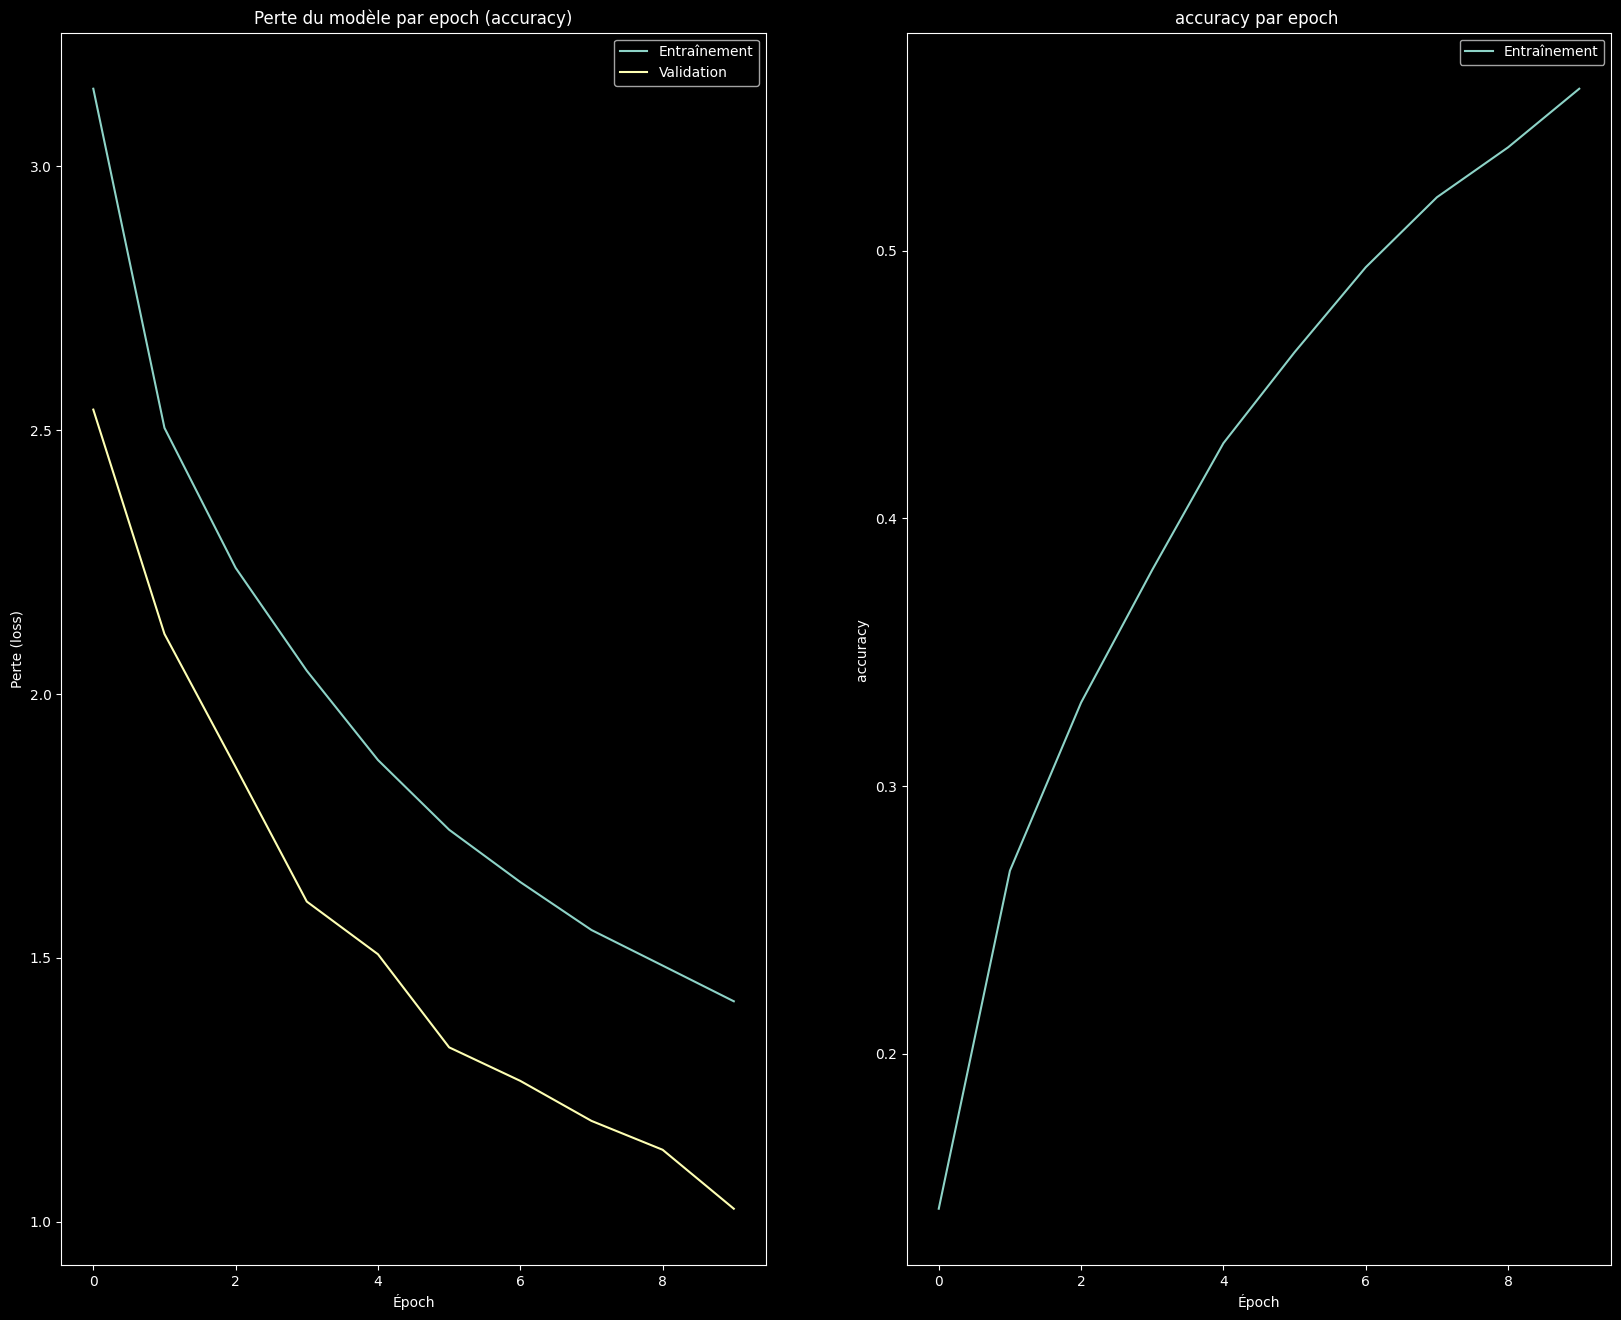

In [31]:
plt.figure(figsize=(20, 16))

# Tracer l'accuracy
plt.subplot(121)
plt.plot(train_loss)
plt.plot(val_loss)
plt.title('Perte du modèle par epoch (accuracy)')
plt.ylabel('Perte (loss)')
plt.xlabel('Époch')
plt.legend(['Entraînement', 'Validation'], loc='best')

# Tracer l'erreur absolue moyenne (MAE)
plt.subplot(122)
plt.plot(train_accuracy)
#plt.plot(val_mae)
plt.title('accuracy par epoch ')
plt.ylabel('accuracy ')
plt.xlabel('Époch')
plt.legend(['Entraînement', 'Validation'], loc='best')

plt.show()

In [29]:
model.save('mon_modele.keras')
model.save_weights('mes_poids.weights.h5')

In [30]:
from tensorflow.keras.models import load_model
model_loaded = load_model('mon_modele.keras')
model_loaded.summary()

/home/henri/PycharmProjects/JupyterProject/FG_project-template-main/.venv/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 14 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 252, 252, 16)   │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 126, 126, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 124, 124, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         3,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 86,758 (338.90 KB)

 Trainable params: 43,378 (169.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 43,380 (169.46 KB)